# Solving XOR with a Multi-Layer Perceptron
This notebook demonstrates how to solve the classic non-linear XOR problem using a 2-layer Neural Network built entirely with Gradience.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from gradience.tensor import Tensor
from gradience.nn.containers.sequential import Sequential
from gradience.nn.layers.linear import Linear
from gradience.nn.activations.tanh import Tanh
from gradience.nn.activations.sigmoid import Sigmoid
from gradience.nn.losses.mse import MSELoss
from gradience.optim.sgd import SGD

## 1. Define the XOR Dataset
XOR requires a non-linear decision boundary, making it a perfect benchmark for neural networks.

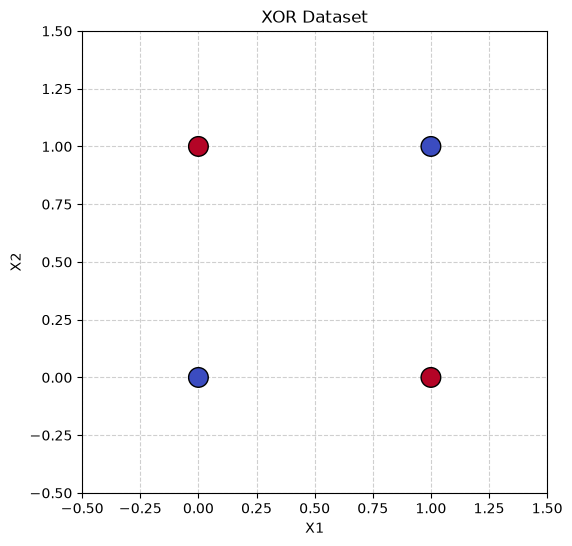

In [2]:
X_data = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])
y_data = np.array([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

plt.figure(figsize=(6, 6))
scatter = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data[:, 0], cmap='coolwarm', s=200, edgecolors='k', zorder=5)
plt.title('XOR Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

X = Tensor(X_data)
y = Tensor(y_data)

## 2. Define the Neural Network Architecture
We will use a `Sequential` container with a hidden layer of 8 neurons and a `Tanh` activation function, followed by an output layer with a `Sigmoid`.

In [3]:
model = Sequential(
    Linear(2, 8),
    Tanh(),
    Linear(8, 1),
    Sigmoid()
)

criterion = MSELoss()
optimizer = SGD(model.parameters(), lr=0.5)

## 3. Training Loop
We will aggressively train the model for 5,000 epochs to ensure convergence.

In [4]:
epochs = 5000
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f'Epoch {epoch+1:04d}/{epochs} | Loss: {loss.item():.4f}')

Epoch 0500/5000 | Loss: 0.0035
Epoch 1000/5000 | Loss: 0.0013
Epoch 1500/5000 | Loss: 0.0008
Epoch 2000/5000 | Loss: 0.0006
Epoch 2500/5000 | Loss: 0.0004
Epoch 3000/5000 | Loss: 0.0003
Epoch 3500/5000 | Loss: 0.0003
Epoch 4000/5000 | Loss: 0.0002
Epoch 4500/5000 | Loss: 0.0002
Epoch 5000/5000 | Loss: 0.0002


## 4. Visualizing the Decision Boundary
By evaluating a grid of points through our trained neural network, we can plot the non-linear decision boundary it learned.

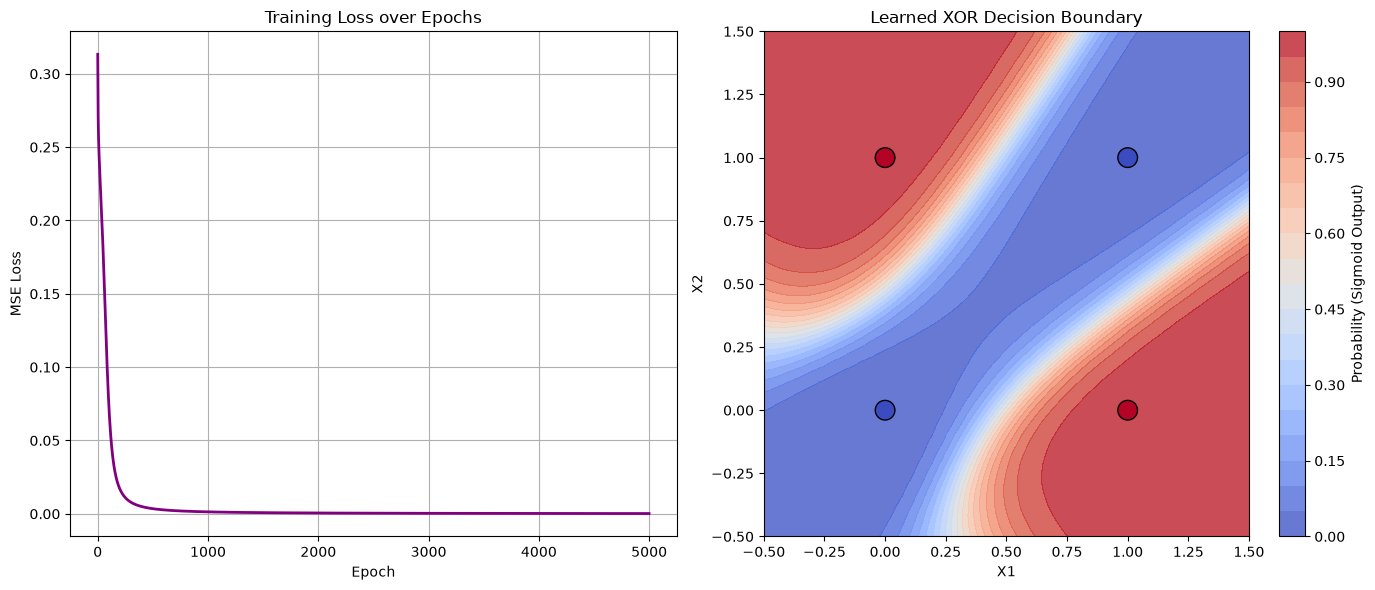

Final Predictions:
Input: [0. 0.] | Expected: 0.0 | Predicted: 0.0091
Input: [0. 1.] | Expected: 1.0 | Predicted: 0.9854
Input: [1. 0.] | Expected: 1.0 | Predicted: 0.9856
Input: [1. 1.] | Expected: 0.0 | Predicted: 0.0161


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss Curve
ax1.plot(losses, color='purple', linewidth=2)
ax1.set_title('Training Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(True)

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 50), np.linspace(-0.5, 1.5, 50))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = Tensor(grid)

# Forward pass on grid
Z = model(grid_tensor).data
Z = Z.reshape(xx.shape)

contour = ax2.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.8)
ax2.scatter(X_data[:, 0], X_data[:, 1], c=y_data[:, 0], cmap='coolwarm', s=200, edgecolors='k', zorder=5)
ax2.set_title('Learned XOR Decision Boundary')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
fig.colorbar(contour, ax=ax2, label='Probability (Sigmoid Output)')

plt.tight_layout()
plt.show()

# Final Predictions Printout
print('Final Predictions:')
final_preds = model(X)
for i in range(len(X_data)):
    print(f'Input: {X_data[i]} | Expected: {y_data[i][0]} | Predicted: {final_preds.data[i][0]:.4f}')

## 5. PyTorch Comparison
Let's build the exact same 2-layer MLP in PyTorch and train it on the XOR dataset to verify our framework's capabilities.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

X_pt = torch.tensor(X_data, dtype=torch.float32)
y_pt = torch.tensor(y_data, dtype=torch.float32)

pt_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

pt_criterion = nn.MSELoss()
pt_optimizer = optim.SGD(pt_model.parameters(), lr=0.5)

pt_losses = []

for epoch in range(epochs):
    pt_optimizer.zero_grad()
    preds = pt_model(X_pt)
    loss = pt_criterion(preds, y_pt)
    loss.backward()
    pt_optimizer.step()
    
    pt_losses.append(loss.item())

### Plot Gradience vs PyTorch

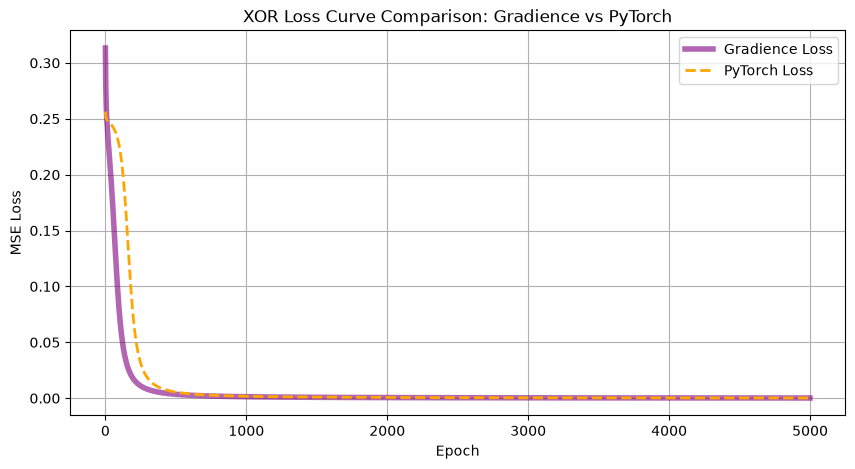

Gradience Predictions:
[0.00912218 0.98535898 0.98555934 0.01606206]
PyTorch Predictions:
[0.01038523 0.98417956 0.9839125  0.0169911 ]


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(losses, color='purple', linewidth=4, alpha=0.6, label='Gradience Loss')
plt.plot(pt_losses, color='orange', linewidth=2, linestyle='--', label='PyTorch Loss')
plt.title('XOR Loss Curve Comparison: Gradience vs PyTorch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

print('Gradience Predictions:')
print(model(X).data.flatten())
print('PyTorch Predictions:')
with torch.no_grad():
    print(pt_model(X_pt).numpy().flatten())